In [42]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import urllib.request
import statbotics
import json

sb = statbotics.Statbotics()

#type in teams in the competition

event = '2026cagle'

#Year of record
year = 2026

# The team whose strength you want to compare against the rest of the event
my_team = 2429

accept_header = 'application/json'
import os
import getpass
from pathlib import Path

def find_up(filename, start=None, max_up=5):
    """Search the current dir and its parents for `filename`.

    The notebook kernel's working directory doesn't always match the
    notebook's own folder (this varies by Jupyter frontend), so a plain
    relative Path(".tba_auth_key") can silently miss the key file and fall
    through to an easy-to-miss getpass prompt. Searching upward makes the
    lookup work regardless of where the kernel started.
    """
    p = Path(start or os.getcwd()).resolve()
    for _ in range(max_up):
        candidate = p / filename
        if candidate.is_file():
            return candidate
        if p.parent == p:
            break
        p = p.parent
    return None

if os.environ.get("TBA_AUTH_KEY"):
    auth_key = os.environ["TBA_AUTH_KEY"]
else:
    key_file = find_up(".tba_auth_key")
    if key_file is not None:
        auth_key = key_file.read_text(encoding="utf-8").strip()
    else:
        print(f"No TBA_AUTH_KEY env var or .tba_auth_key found near {os.getcwd()} - prompting for input.")
        auth_key = getpass.getpass("TBA X-TBA-Auth-Key: ")

def tba_get(path):
    req = urllib.request.Request('https://www.thebluealliance.com/api/v3' + path)
    req.add_header('accept', accept_header)
    req.add_header('X-TBA-Auth-Key', auth_key)
    req.add_header('User-Agent', '1895_Scouter')
    with urllib.request.urlopen(req, timeout=15) as response:
        return json.loads(response.read())

# TBA event_type codes: 3/4/5 are Championship Division/Finals/District-Champs-Division,
# i.e. events that are part of a FIRST World Championship.
CHAMPIONSHIP_EVENT_TYPES = {3, 4, 5}

print(f'Looking up event name for {event}...')
try:
    event_info = tba_get('/event/' + event)
    event_name = event_info.get('name', event)
    if event_info.get('event_type') in CHAMPIONSHIP_EVENT_TYPES:
        event_label = f'World Championship {event_name}'
    else:
        event_label = event_name
except Exception as e:
    print('Could not fetch event info, falling back to raw event code:', e)
    event_label = event

title = f'{year} {event_label} Rev.{datetime.date.today()}'

print(f'Fetching teams for {event} from TBA...')
teams_j = tba_get('/event/' + event + '/teams')
print(f'Got {len(teams_j)} teams.')

Looking up event name for 2026cagle...
Fetching teams for 2026cagle from TBA...
Got 37 teams.


In [43]:
teams = []
for i in np.arange(len(teams_j)):
    teams = np.append(teams, int(teams_j[i]['team_number']))

In [44]:
print(teams)
if my_team in teams:
    print(f'Team {my_team} is in the event')
    presence = True
else:
    print(f'Team {my_team} is NOT in the event')
    teams = np.append(teams, my_team)
    presence = False

[1.0147e+04 1.0166e+04 1.0936e+04 1.1024e+04 1.1480e+03 2.2000e+01
 2.4040e+03 2.4290e+03 2.6590e+03 3.2550e+03 3.3280e+03 3.5010e+03
 3.5120e+03 3.9650e+03 4.0000e+00 4.9640e+03 5.0260e+03 5.0890e+03
 5.9700e+02 6.0000e+03 6.0360e+03 6.5600e+03 6.6580e+03 6.9340e+03
 6.9600e+02 6.9950e+03 7.0200e+02 7.3230e+03 7.4150e+03 8.0330e+03
 8.0600e+03 8.5330e+03 9.0840e+03 9.5050e+03 9.5200e+03 9.6960e+03
 9.7720e+03]
Team 2429 is in the event


In [45]:
dtype = [('team_no',int), ('epa', float),('auto_epa_end', float),('teleop_epa_end', float), ('endgame_epa_end', float), ('name', str, 50)]
teams_epa = np.array([], dtype=dtype)

for i in teams:
    try:
        data = sb.get_team_year(int(i), year)
        teams_epa = np.append(teams_epa, np.array((i, data['epa']['breakdown']['total_points'], data['epa']['breakdown']['auto_points'], 
                                                   data['epa']['breakdown']['teleop_points'], data['epa']['breakdown']['endgame_points'], data['name']), dtype=dtype))
    except:
        print('exception happend with team#', int(i))

teams_sorted = np.sort(teams_epa, order=['epa'])[::-1]  #sorting stronger teams first
teams_count = len(teams) - (not presence) * 1

In [46]:
def plot_epa_comparison(teams_sorted, my_team, teams_count, presence, title, top_n=20, xlim=None, ylim=None, xmin=None):
    """Two-panel view: a readable ranked list on the left, EPA scatter on the right.

    Any team number can be passed as `my_team` and it will be highlighted in
    both the list and the scatter plot. xlim/ylim/xmin default to auto-scaling
    off this event's own EPA spread, since a weaker or stronger field can sit
    on a very different EPA scale than a fixed axis range assumes.
    """
    n_list = int(min(top_n, len(teams_sorted)))

    x_vals = teams_sorted['teleop_epa_end']
    y_vals = teams_sorted['auto_epa_end'] + teams_sorted['endgame_epa_end']

    if xmin is None or xlim is None:
        x_pad = max((x_vals.max() - x_vals.min()) * 0.1, 5)
        if xmin is None:
            xmin = min(0, x_vals.min() - x_pad)
        if xlim is None:
            xlim = x_vals.max() + x_pad
    if ylim is None:
        y_pad = max((y_vals.max() - y_vals.min()) * 0.1, 5)
        ylim = y_vals.max() + y_pad

    fig, (ax_list, ax_scatter) = plt.subplots(
        1, 2, figsize=(8, min(6, max(4, 0.2 * n_list))), gridspec_kw={'width_ratios': [1, 1.6]}
    )

    # --- left panel: ranked list, one row per team, monospace so columns line up ---
    ax_list.axis('off')
    ax_list.set_ylim(0, 1)
    ax_list.set_xlim(0, 1)

    ax_list.text(0, 1.00, f'Top {n_list} of {teams_count} teams', transform=ax_list.transAxes,
                 fontsize=10, fontweight='bold', va='top', family='monospace')
    ax_list.text(0, 0.95, f'{"rk":>2}  {"EPA":>7}  team', transform=ax_list.transAxes,
                 fontsize=8, va='top', family='monospace')

    row_top = 0.90
    # +2 reserves a blank row of space below the last team before the
    # participation line, so it doesn't crowd the last row of the list.
    row_height = row_top / (n_list + 2)
    for i in range(n_list):
        team = teams_sorted[i]
        is_me = int(team['team_no']) == my_team
        line = f'{i + 1:>2}  {team["epa"]:>7.2f}  {int(team["team_no"])}-{team["name"][:20]}'
        ax_list.text(0, row_top - i * row_height, line, transform=ax_list.transAxes,
                     fontsize=8, va='top', family='monospace',
                     color='red' if is_me else 'black',
                     fontweight='bold' if is_me else 'normal')

    participation_y = row_top - (n_list + 1) * row_height
    ax_list.text(0, participation_y, f'{my_team} participation: {presence}', transform=ax_list.transAxes,
                 fontsize=8, va='top', family='monospace')

    # --- right panel: scatter of teleop vs auto+endgame EPA ---
    for team in teams_sorted:
        x = team['teleop_epa_end']
        y = team['auto_epa_end'] + team['endgame_epa_end']
        is_me = int(team['team_no']) == my_team
        ax_scatter.scatter(x, y, c='red' if is_me else 'skyblue',
                            edgecolor='red' if is_me else 'deepskyblue',
                            zorder=3 if is_me else 2)
        ax_scatter.annotate(str(int(team['team_no'])), xy=(x - 0.75, y + 0.5), fontsize=6,
                             color='red' if is_me else 'black')

    ax_scatter.set_xlim(xmin, xlim)
    ax_scatter.set_ylim(0, ylim)
    ax_scatter.set_xlabel('Teleop')
    ax_scatter.set_ylabel('Auto + Endgame')
    ax_scatter.set_title(title, fontsize=10)

    fig.tight_layout()
    return fig

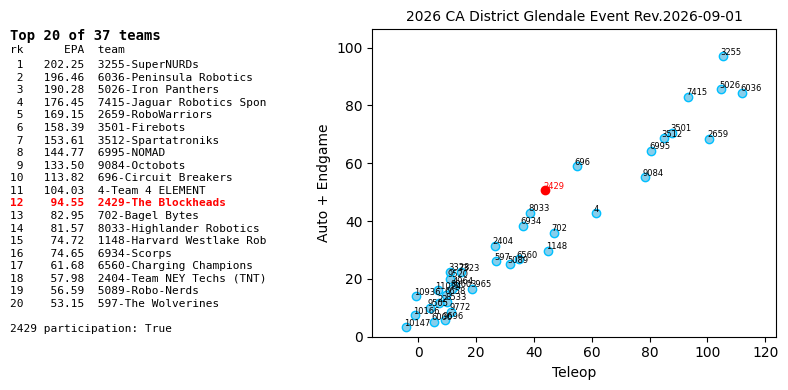

In [47]:
plot_epa_comparison(teams_sorted, my_team, teams_count, presence, title, top_n=20)
plt.show()

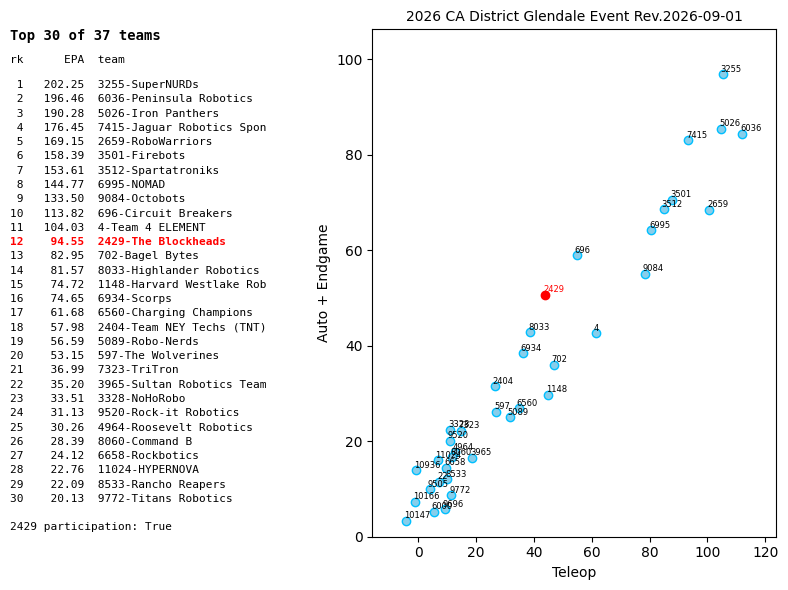

In [48]:
plot_epa_comparison(teams_sorted, my_team, teams_count, presence, title, top_n=30)
plt.show()

In [ ]:
import requests
r = requests.get(f"https://api.statbotics.io/v3/team_year/{my_team}/{year}")
print(r.status_code, r.text[:300])